
# Molecular Description Practical: Topology, Structure and Force Fields
### A GAFF simulation of liquid ethanol (100 molecules) with OpenMM

**Learning objectives**

By the end of this notebook you should be able to:

1. Explain the difference between a **chemical structure**, a **topology**, and a **force field**, and see how each one is represented as data in a molecular simulation.
2. Assign **GAFF (General Amber Force Field)** atom types and partial charges to a small molecule "by hand", and understand what a force field parameter file actually contains.
3. Build a **periodic simulation box** containing many copies of a molecule, and understand why periodic boundary conditions (PBC) are used.
4. Run the four classic stages of a liquid-phase molecular dynamics (MD) protocol: **energy minimization → NVT equilibration → NPT equilibration → NPT production**, and understand what each stage is *for*.
5. Compute and interpret **temperature, pressure, volume and density** from an MD trajectory, and relate the fluctuations you see back to basic statistical mechanics (ensembles, the virial theorem).

**A note on the force field parametrization used here.** The standard way of getting GAFF atom types and AM1-BCC partial charges for a new molecule is to run `antechamber` from AmberTools. That program is not pip-installable and needs a full conda/AmberTools environment, which is heavier than what we want for a 3-hour course on a laptop with 4 cores / 8 GB RAM. Instead, in this notebook we:

- assign the GAFF atom types **manually**, which is actually *more* instructive for a first course, since you will literally see how each atom's chemical environment determines its type;
- compute partial charges with RDKit's fast **Gasteiger** method instead of AM1-BCC.

The results are therefore **not research-grade** (Gasteiger charges are a rough approximation), but the whole pipeline — topology, atom typing, bonded/non-bonded parameters, PBC, ensembles — is exactly the one you would use with a "real" AM1-BCC/GAFF parametrization. We call this out explicitly wherever it matters.

**Estimated running time:** the MD steps themselves run in a few minutes on 4 CPU cores; including package installation, plotting and visualization the whole notebook should comfortably finish in well under 20 minutes.



## 0. Environment setup

We only need packages that install cleanly with `pip` (no conda, no compiled AmberTools):

| Package | Role |
|---|---|
| `openmm` | runs the molecular dynamics |
| `openmmforcefields` | ships a ready-to-use OpenMM XML version of the GAFF parameter set (bonded + van der Waals parameters per atom type) |
| `rdkit` | builds the 2D/3D structure of ethanol and computes Gasteiger partial charges |
| `numpy`, `matplotlib` | numerics and plotting |
| `py3Dmol` | lightweight, dependency-free 3D molecular viewer that works reliably inside Jupyter |

Run the cell below once. If you are working offline, make sure these were installed ahead of time.


In [1]:
# Uncomment if the packages are not yet installed in your environment
# %pip install --quiet openmm openmmforcefields rdkit py3Dmol numpy matplotlib


In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem

import openmm as mm
import openmmforcefields
from openmm import app, unit

import py3Dmol

# Reproducibility: fix the random seed used for packing the box and for velocities
SEED = 42
rng = np.random.default_rng(SEED)

print("OpenMM version:", mm.version.version)
print("Available OpenMM platforms:", [mm.Platform.getPlatform(i).getName()
                                       for i in range(mm.Platform.getNumPlatforms())])


OpenMM version: 8.6.0.dev-c6173db
Available OpenMM platforms: ['Reference', 'CPU', 'CUDA', 'OpenCL']



## 1. Structure: from a chemical formula to 3D coordinates

A **structure** is just a set of atoms placed in 3D space, plus the knowledge of which element each atom is. It says nothing yet about *how* those atoms interact with each other — that will come later, with the force field.

We start from the SMILES string for ethanol, `CCO`, add explicit hydrogens, embed a 3D conformation, and do a quick, cheap geometry optimization with the MMFF force field (used here *only* to get a reasonable starting geometry — MMFF is not the force field we will simulate with).


In [2]:
# Build a single ethanol molecule and give it 3D coordinates
mol = Chem.MolFromSmiles("CCO")
mol = Chem.AddHs(mol)                       # SMILES by default hides hydrogens
AllChem.EmbedMolecule(mol, randomSeed=SEED) # generate an initial 3D conformer
AllChem.MMFFOptimizeMolecule(mol)           # relax it with a generic force field (MMFF)
AllChem.ComputeGasteigerCharges(mol)        # fast empirical partial charges

conf = mol.GetConformer()
print(f"Ethanol has {mol.GetNumAtoms()} atoms (structure = atoms + 3D coordinates)")
for atom in mol.GetAtoms():
    pos = conf.GetAtomPosition(atom.GetIdx())
    print(f"  idx {atom.GetIdx()}: {atom.GetSymbol():2s}  "
          f"xyz=({pos.x:6.3f}, {pos.y:6.3f}, {pos.z:6.3f}) A")


Ethanol has 9 atoms (structure = atoms + 3D coordinates)
  idx 0: C   xyz=(-0.888,  0.167, -0.027) A
  idx 1: C   xyz=( 0.466, -0.512, -0.037) A
  idx 2: O   xyz=( 1.431,  0.323,  0.587) A
  idx 3: H   xyz=(-0.849,  1.117, -0.570) A
  idx 4: H   xyz=(-1.647, -0.470, -0.490) A
  idx 5: H   xyz=(-1.196,  0.398,  0.998) A
  idx 6: H   xyz=( 0.792, -0.722, -1.060) A
  idx 7: H   xyz=( 0.425, -1.456,  0.514) A
  idx 8: H   xyz=( 1.467,  1.155,  0.085) A


In [3]:
# Visualize the single molecule -- this is a *structure*: atoms + geometry, no force field yet
mol_block = Chem.MolToMolBlock(mol)

view = py3Dmol.view(width=400, height=350)
view.addModel(mol_block, "mol")
view.setStyle({"stick": {"radius": 0.15}, "sphere": {"scale": 0.25}})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


## 2. Topology: describing *connectivity*, independent of geometry

A **topology** is the graph of atoms and bonds: which atom is bonded to which, grouped into residues and chains. Two molecules can have the *same topology* (same connectivity) but different *structures* (different 3D coordinates) — for example, two different conformers of ethanol. Conversely, a force field is defined in terms of the topology (bonded terms are "the bond between atom type X and atom type Y"), not in terms of any particular geometry.

OpenMM keeps topology and coordinates as two separate objects on purpose:

- `openmm.app.Topology`: chains → residues → atoms, plus bonds. No coordinates.
- `positions`: a plain array of 3D coordinates, one per atom, matching the order of the topology.

Below we build the OpenMM `Topology` for a single ethanol molecule **by hand**, atom by atom, so that the relationship between "structure" (the RDKit molecule above) and "topology" (the OpenMM object below) is completely explicit.


In [4]:
# Give the 9 atoms of ethanol human-readable names.
# Numbering matches the RDKit atom order printed in Section 1:
# 0:C1(CH3) 1:C2(CH2) 2:O1 3-5:H on C1  6-7:H on C2  8:H on O1
atom_names = ["C1", "C2", "O1", "H11", "H12", "H13", "H21", "H22", "HO1"]

element_map = {
    "C1": app.element.carbon,  "C2": app.element.carbon,  "O1": app.element.oxygen,
    "H11": app.element.hydrogen, "H12": app.element.hydrogen, "H13": app.element.hydrogen,
    "H21": app.element.hydrogen, "H22": app.element.hydrogen, "HO1": app.element.hydrogen,
}

# Bonds, given as pairs of RDKit atom indices (0-based), read directly off the structure above
bonds_idx = [(0, 1), (1, 2), (0, 3), (0, 4), (0, 5), (1, 6), (1, 7), (2, 8)]

def make_ethanol_topology():
    """Build a fresh OpenMM Topology containing a single ETH residue."""
    top = app.Topology()
    chain = top.addChain()
    res = top.addResidue("ETH", chain)
    atoms = [top.addAtom(name, element_map[name], res) for name in atom_names]
    for i, j in bonds_idx:
        top.addBond(atoms[i], atoms[j])
    return top, atoms

single_top, single_atoms = make_ethanol_topology()

print("Topology summary for one ethanol molecule:")
print(f"  chains:   {single_top.getNumChains()}")
print(f"  residues: {single_top.getNumResidues()}  (name: 'ETH')")
print(f"  atoms:    {single_top.getNumAtoms()}")
print(f"  bonds:    {single_top.getNumBonds()}")
print()
print("Bond list (topology only -- no lengths, no angles, no energies yet):")
for b in single_top.bonds():
    print(f"  {b[0].name:4s} -- {b[1].name:4s}")


Topology summary for one ethanol molecule:
  chains:   1
  residues: 1  (name: 'ETH')
  atoms:    9
  bonds:    8

Bond list (topology only -- no lengths, no angles, no energies yet):
  C1   -- C2  
  C2   -- O1  
  C1   -- H11 
  C1   -- H12 
  C1   -- H13 
  C2   -- H21 
  C2   -- H22 
  O1   -- HO1 



## 3. Force field: turning atom identity into interaction parameters (GAFF)

A structure tells you *where* the atoms are. A topology tells you *how* they are connected. Neither tells you *how strongly* they interact, or what happens if you move them. That is the job of the **force field**.

GAFF does this in two steps:

1. **Atom typing** — every atom is assigned a *type* based on its element **and its chemical environment** (hybridization, what it's bonded to). This is why a generic "C" is not enough: an sp3 carbon (`c3`) behaves very differently from an aromatic carbon (`ca`) or a carbonyl carbon (`c`). GAFF has dozens of these atom types, each with its own bonded and van der Waals parameters.
2. **Parameter lookup** — bond, angle, and torsion parameters are looked up *by the pair/triplet/quadruplet of atom types involved*, not by atom identity or molecule. This is what makes a force field transferable: the `c3`-`oh` bond parameters we use for ethanol's C-O bond are the same ones GAFF would use in any other molecule containing that same local environment.

For our 9-atom ethanol molecule, the standard, well-known GAFF atom types are:

| atom | element | GAFF type | meaning |
|---|---|---|---|
| C1  | C | `c3` | sp3 carbon |
| C2  | C | `c3` | sp3 carbon |
| O1  | O | `oh` | hydroxyl oxygen |
| H11,H12,H13,H21,H22 | H | `hc` | H bonded to an sp3 carbon |
| HO1 | H | `ho` | H bonded to a hydroxyl oxygen |

We also need a **partial charge** per atom (the non-bonded electrostatic term is not looked up by type — it is specific to *this* molecule). As explained in Section 0, we use RDKit's Gasteiger charges here instead of AM1-BCC.


In [5]:
# Manual GAFF atom-type assignment (see table above)
atom_types = ["c3", "c3", "oh", "hc", "hc", "hc", "hc", "hc", "ho"]

# Gasteiger partial charges, computed in Section 1, in the same atom order.
# We force them to sum EXACTLY to zero (neutral molecule); Gasteiger charges are
# only approximately neutral due to floating point / algorithmic truncation.
raw_charges = np.array([float(a.GetProp("_GasteigerCharge")) for a in mol.GetAtoms()])
charges = raw_charges - raw_charges.mean()

print(f"{'atom':5s} {'element':8s} {'GAFF type':10s} {'charge (e)':>10s}")
for name, atype, chg in zip(atom_names, atom_types, charges):
    element = element_map[name].symbol
    print(f"{name:5s} {element:8s} {atype:10s} {chg:10.4f}")
print(f"\nSum of charges (should be ~0): {charges.sum():.2e}")


atom  element  GAFF type  charge (e)
C1    C        c3            -0.0418
C2    C        c3             0.0402
O1    O        oh            -0.3967
H11   H        hc             0.0254
H12   H        hc             0.0254
H13   H        hc             0.0254
H21   H        hc             0.0561
H22   H        hc             0.0561
HO1   H        ho             0.2100

Sum of charges (should be ~0): 2.78e-17


In [6]:
# Locate the GAFF force field parameters bundled with openmmforcefields.
# This XML file was generated from AmberTools' gaff-2.11.dat and contains, PER ATOM TYPE:
# bond, angle and torsion parameters, and Lennard-Jones (van der Waals) sigma/epsilon.
GAFF_XML = os.path.join(
    os.path.dirname(openmmforcefields.__file__),
    "ffxml", "amber", "gaff", "ffxml", "gaff-2.11.xml",
)
assert os.path.exists(GAFF_XML), "Could not find the bundled GAFF ffxml file"
print("Using GAFF parameter file:", GAFF_XML)

def ethanol_residue_xml(charges):
    """
    Build the small OpenMM ffxml snippet that is specific to OUR molecule:
    which GAFF type and which partial charge goes on each named atom, and
    the bond connectivity (matching the Topology built in Section 2).
    Everything else (actual bond/angle/torsion/vdW parameters) is looked up
    from the generic GAFF file by atom type -- that part is NOT molecule specific.
    """
    atoms_xml = "\n".join(
        f'      <Atom name="{n}" type="{t}" charge="{c:.6f}"/>'
        for n, t, c in zip(atom_names, atom_types, charges)
    )
    bonds_xml = "\n".join(
        f'      <Bond atomName1="{atom_names[i]}" atomName2="{atom_names[j]}"/>'
        for i, j in bonds_idx
    )
    return f"""<ForceField>
  <Residues>
    <Residue name="ETH">
{atoms_xml}
{bonds_xml}
    </Residue>
  </Residues>
</ForceField>"""

residue_xml_path = "ethanol_residue.xml"
with open(residue_xml_path, "w") as f:
    f.write(ethanol_residue_xml(charges))

# Combine: generic GAFF atom-type parameters + our molecule-specific residue template
forcefield = app.ForceField(GAFF_XML, residue_xml_path)
print("Force field ready: generic GAFF parameters + ethanol ('ETH') residue template")


Using GAFF parameter file: /home/tanguma_ah/.conda/envs/molsim_autum/lib/python3.13/site-packages/openmmforcefields/ffxml/amber/gaff/ffxml/gaff-2.11.xml
Force field ready: generic GAFF parameters + ethanol ('ETH') residue template


In [7]:
# Sanity check: build a System for ONE ethanol molecule and inspect what the
# force field actually produced, to make the topology -> parameters link explicit.
test_system = forcefield.createSystem(single_top, nonbondedMethod=app.NoCutoff)

print("Forces present in the System (one per interaction TYPE, not per atom):")
for force in test_system.getForces():
    print(" -", force.getName())

# Pull out the actual bonded parameters OpenMM assigned to the C1-C2 bond (c3-c3)
bond_force = [f for f in test_system.getForces() if isinstance(f, mm.HarmonicBondForce)][0]
print("\nHarmonicBondForce parameters (index i, index j, length, force constant):")
for b in range(bond_force.getNumBonds()):
    i, j, length, k = bond_force.getBondParameters(b)
    name_i, name_j = atom_names[i], atom_names[j]
    print(f"  {name_i:4s}-{name_j:<4s}  r0 = {length.value_in_unit(unit.nanometer):.4f} nm   "
          f"k = {k.value_in_unit(unit.kilojoule_per_mole/unit.nanometer**2):8.1f} kJ/mol/nm^2")


Forces present in the System (one per interaction TYPE, not per atom):
 - HarmonicBondForce
 - PeriodicTorsionForce
 - NonbondedForce
 - CMMotionRemover
 - HarmonicAngleForce

HarmonicBondForce parameters (index i, index j, length, force constant):
  C1  -C2    r0 = 0.1538 nm   k = 194556.0 kJ/mol/nm^2
  C2  -O1    r0 = 0.1423 nm   k = 245517.1 kJ/mol/nm^2
  C1  -H11   r0 = 0.1097 nm   k = 314553.1 kJ/mol/nm^2
  C1  -H12   r0 = 0.1097 nm   k = 314553.1 kJ/mol/nm^2
  C1  -H13   r0 = 0.1097 nm   k = 314553.1 kJ/mol/nm^2
  C2  -H21   r0 = 0.1097 nm   k = 314553.1 kJ/mol/nm^2
  C2  -H22   r0 = 0.1097 nm   k = 314553.1 kJ/mol/nm^2
  O1  -HO1   r0 = 0.0973 nm   k = 471536.8 kJ/mol/nm^2



Notice that the C1-C2 and C1-H bond parameters are exactly what you would expect from the atom types alone (`c3`-`c3` and `c3`-`hc`) — this is the essence of a transferable force field: **the parameters live on the topology + atom types, not on the specific molecule**.



## 4. Building the simulation box: 100 ethanol molecules under periodic boundary conditions

A single molecule in vacuum cannot tell us anything about *bulk liquid* properties like density. To simulate a liquid we need:

1. **Many copies** of the molecule (100, here) so that each one experiences a realistic liquid-like environment.
2. **Periodic boundary conditions (PBC):** the box is replicated infinitely in all directions, so a molecule that exits on the right re-enters on the left. This removes artificial "surface"/vacuum effects and lets a modest number of molecules behave like an (approximately) infinite bulk liquid.

**A deliberate choice:** instead of trying to guess the correct experimental density (0.789 g/mL for ethanol at room temperature) and packing the molecules that tightly from the start, we place them on a grid **more loosely** than that. Packing 100 flexible molecules at the exact liquid density by hand nearly always creates severe atomic clashes (two atoms on top of each other), which can make the very first energy evaluation blow up numerically. Instead we:

- start intentionally a bit too dilute (moderate, controlled clashes only),
- let **energy minimization** remove the remaining bad contacts,
- let **NPT equilibration** (Section 7) do the physically correct thing: shrink the box under a barostat until the pressure balances at 1 atm, at which point the density should approach the real liquid value.

This is standard practice, and it doubles as a nice illustration of the barostat actually "doing its job".


In [8]:
N_MOLECULES = 100
NX, NY, NZ = 5, 5, 4          # 5 x 5 x 4 = 100 grid cells
SPACING = 0.45                # nm between grid points (intentionally loose, see note above)
PADDING = 0.5                 # nm of extra empty space added around the grid

def pack_box(n_molecules=N_MOLECULES, nx=NX, ny=NY, nz=NZ, spacing=SPACING, padding=PADDING, seed=SEED):
    """
    Place n_molecules copies of ethanol on a regular grid, each with a random
    rotation and a small random jitter, and build the corresponding OpenMM
    Topology (single chain, one 'ETH' residue per molecule) and box vectors.
    """
    assert nx * ny * nz >= n_molecules
    local_rng = np.random.default_rng(seed)

    base_pos = np.array(conf.GetPositions()) / 10.0   # Angstrom -> nm
    base_pos -= base_pos.mean(axis=0)                  # center each molecule at the origin

    top = app.Topology()
    chain = top.addChain()
    all_positions = []

    count = 0
    for ix in range(nx):
        for iy in range(ny):
            for iz in range(nz):
                if count >= n_molecules:
                    break
                res = top.addResidue("ETH", chain)
                atoms = [top.addAtom(name, element_map[name], res) for name in atom_names]
                for i, j in bonds_idx:
                    top.addBond(atoms[i], atoms[j])

                # random rotation matrix (uniform Euler angles -- good enough here)
                theta = local_rng.uniform(0, 2 * np.pi, size=3)
                Rx = np.array([[1, 0, 0],
                               [0, np.cos(theta[0]), -np.sin(theta[0])],
                               [0, np.sin(theta[0]),  np.cos(theta[0])]])
                Ry = np.array([[ np.cos(theta[1]), 0, np.sin(theta[1])],
                               [0, 1, 0],
                               [-np.sin(theta[1]), 0, np.cos(theta[1])]])
                Rz = np.array([[np.cos(theta[2]), -np.sin(theta[2]), 0],
                               [np.sin(theta[2]),  np.cos(theta[2]), 0],
                               [0, 0, 1]])
                R = Rx @ Ry @ Rz

                center = np.array([ix, iy, iz]) * spacing
                jitter = local_rng.uniform(-0.03, 0.03, size=3)
                all_positions.append((base_pos @ R.T) + center + jitter)
                count += 1

    positions = np.vstack(all_positions) * unit.nanometer
    box = np.array([nx * spacing + padding, ny * spacing + padding, nz * spacing + padding])
    box_vectors = [[box[0], 0, 0], [0, box[1], 0], [0, 0, box[2]]]
    top.setPeriodicBoxVectors(box_vectors)
    return top, positions, np.array(box_vectors)

topology, positions, box_vectors = pack_box()

ETHANOL_MOLAR_MASS = 46.07  # g/mol
total_mass_g = N_MOLECULES * ETHANOL_MOLAR_MASS / 6.02214076e23

def box_volume_nm3(box_vectors):
    return np.linalg.det(box_vectors)

def density_g_per_mL(box_vectors, mass_g=total_mass_g):
    vol_nm3 = box_volume_nm3(box_vectors)
    vol_cm3 = vol_nm3 * 1e-21   # 1 nm^3 = 1e-21 cm^3
    return mass_g / vol_cm3

print(f"Topology: {topology.getNumResidues()} residues, {topology.getNumAtoms()} atoms")
print(f"Box vectors (nm):\n{box_vectors}")
print(f"Box volume: {box_volume_nm3(box_vectors):.2f} nm^3")
print(f"Starting density: {density_g_per_mL(box_vectors):.3f} g/mL  "
      f"(experimental liquid ethanol ~0.789 g/mL -- we start below this on purpose)")


Topology: 100 residues, 900 atoms
Box vectors (nm):
[[2.75 0.   0.  ]
 [0.   2.75 0.  ]
 [0.   0.   2.3 ]]
Box volume: 17.39 nm^3
Starting density: 0.440 g/mL  (experimental liquid ethanol ~0.789 g/mL -- we start below this on purpose)


In [21]:
# Reusable visualization helper: renders the box, wrapping molecules back into
# the primary cell (enforcePeriodicBox), and draws the periodic box as a wireframe cube.
def render_box(topology, positions_nm, box_vectors, title=None, width=450, height=400):
    pdb_path = "_frame.pdb"
    with open(pdb_path, "w") as f:
        app.PDBFile.writeFile(topology, positions_nm * unit.nanometer if not hasattr(positions_nm, "unit") else positions_nm, f)

    view = py3Dmol.view(width=width, height=height)
    view.addModel(open(pdb_path).read(), "pdb")
    view.setStyle({"stick": {"radius": 0.12}})

    cx, cy, cz = box_vectors[0][0] / 2, box_vectors[1][1] / 2, box_vectors[2][2] / 2
    # py3Dmol works in Angstrom, our box_vectors are in nm -> convert.
    # IMPORTANT: addBox takes ONE combined spec dict (geometry + style together).
    # Passing geometry and style as two separate dicts (as before) makes py3Dmol
    # silently ignore "wireframe" and draw a solid, opaque box that hides the interior.
    view.addBox({
        "center": {"x": cx * 10, "y": cy * 10, "z": cz * 10},
        "dimensions": {"w": box_vectors[0][0] * 10, "h": box_vectors[1][1] * 10, "d": box_vectors[2][2] * 10},
        "wireframe": True,
        "linewidth": 1.5,
        "color": "black",
    })
    view.zoomTo()
    if title:
        print(title)
    view.show()


def positions_from_state(simulation):
    """Return wrapped (all molecules inside the primary box) positions as a plain nm array."""
    state = simulation.context.getState(getPositions=True, enforcePeriodicBox=True)
    return state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)


def current_box_vectors(simulation):
    vecs = simulation.context.getState().getPeriodicBoxVectors(asNumpy=True).value_in_unit(unit.nanometer)
    return np.array(vecs)


In [22]:
render_box(topology, positions.value_in_unit(unit.nanometer), box_vectors,
           title="BEFORE minimization: 100 ethanol molecules on a loose grid (some clashes expected)")


BEFORE minimization: 100 ethanol molecules on a loose grid (some clashes expected)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


## 5. Building the `System` objects (potential energy function)

An OpenMM `System` combines the topology with the force field parameters into an actual, evaluable potential energy function, plus some simulation-level choices:

- **`nonbondedMethod=PME`**: Particle Mesh Ewald, the standard accurate way of handling long-range electrostatics under PBC.
- **`constraints=HBonds`**: bonds to hydrogen are held rigid. This is a very common approximation (X-H bonds vibrate too fast to be relevant to the properties we care about) that lets us use a larger integration time step (2 fs instead of ~0.5 fs).
- **Dispersion correction**: an analytic correction for the van der Waals energy beyond the cutoff distance — improves density accuracy for liquids at negligible cost.

We build **two** systems that share the same topology and force field:

- one **without** a barostat, for the constant-volume stages (minimization, NVT);
- one **with** a `MonteCarloBarostat`, for the constant-pressure stages (NPT equilibration, production).

This keeps each ensemble honest: NVT really is constant volume, NPT really is constant pressure.


In [11]:
TEMPERATURE = 300 * unit.kelvin
PRESSURE = 1 * unit.atmosphere
FRICTION = 1 / unit.picosecond
TIMESTEP = 2 * unit.femtoseconds
N_THREADS = "4"   # matches the 4-core machines this notebook is designed for

def make_system(topology, with_barostat):
    system = forcefield.createSystem(
        topology,
        nonbondedMethod=app.PME,
        nonbondedCutoff=0.9 * unit.nanometer,
        constraints=app.HBonds,
    )
    nonbonded = [f for f in system.getForces() if isinstance(f, mm.NonbondedForce)][0]
    nonbonded.setUseDispersionCorrection(True)
    nonbonded.setUseSwitchingFunction(True)
    nonbonded.setSwitchingDistance(0.8 * unit.nanometer)
    if with_barostat:
        # attempt a volume move on average every 25 integrator steps
        system.addForce(mm.MonteCarloBarostat(PRESSURE, TEMPERATURE, 25))
    return system

def make_simulation(topology, system, positions, box_vectors, velocities=None):
    integrator = mm.LangevinMiddleIntegrator(TEMPERATURE, FRICTION, TIMESTEP)
    platform = mm.Platform.getPlatformByName("CPU")
    simulation = app.Simulation(topology, system, integrator, platform, {"Threads": N_THREADS})
    simulation.context.setPeriodicBoxVectors(*box_vectors)
    simulation.context.setPositions(positions)
    if velocities is not None:
        simulation.context.setVelocities(velocities)
    return simulation

def degrees_of_freedom(system):
    """
    Correct number of degrees of freedom for the equipartition-based temperature
    formula T = 2*KE / (n_dof * k_B). Naively using 3*N_atoms OVERCOUNTS degrees
    of freedom whenever constraints (here: all bonds to hydrogen, via HBonds) or
    a CMMotionRemover are present, and would make the reported temperature look
    systematically too LOW compared to the real, thermostatted temperature.
    """
    n_dof = sum(3 for i in range(system.getNumParticles()) if system.getParticleMass(i) > 0 * unit.dalton)
    n_dof -= system.getNumConstraints()
    if any(isinstance(f, mm.CMMotionRemover) for f in system.getForces()):
        n_dof -= 3
    return n_dof

def temperature_kelvin(state, n_dof):
    return (2 * state.getKineticEnergy() / (n_dof * unit.MOLAR_GAS_CONSTANT_R)).value_in_unit(unit.kelvin)

system_nvt = make_system(topology, with_barostat=False)
simulation = make_simulation(topology, system_nvt, positions, box_vectors)
ndof = degrees_of_freedom(system_nvt)
print(f"Degrees of freedom used for temperature: {ndof} (naive 3N would be {3 * topology.getNumAtoms()})")

state = simulation.context.getState(getEnergy=True)
print(f"Potential energy of the freshly packed box: {state.getPotentialEnergy()}")
print("(A large positive number here is expected -- it reflects the atomic clashes")
print(" from the loose grid packing, and is exactly what minimization will fix.)")


Degrees of freedom used for temperature: 2097 (naive 3N would be 2700)
Potential energy of the freshly packed box: 80974.33400948784 kJ/mol
(A large positive number here is expected -- it reflects the atomic clashes
 from the loose grid packing, and is exactly what minimization will fix.)



## 6. Stage 1 — Energy minimization

Minimization performs a *local, deterministic* search for a nearby lower-energy configuration. Its only job here is to remove the unphysically close contacts introduced by our naive grid packing, so that the following MD steps don't start with enormous forces.

Minimization does **not** sample an ensemble and does **not** advance time — there is no notion of temperature or pressure during this stage.


In [12]:
t0 = time.time()
simulation.minimizeEnergy(maxIterations=2000)
print(f"Minimization finished in {time.time() - t0:.1f} s")

state = simulation.context.getState(getEnergy=True)
print(f"Potential energy after minimization: {state.getPotentialEnergy()}")


Minimization finished in 1.0 s
Potential energy after minimization: -709.598097174089 kJ/mol


In [23]:
render_box(topology, positions_from_state(simulation), current_box_vectors(simulation),
           title="AFTER minimization: worst atomic clashes removed, box size unchanged")


AFTER minimization: worst atomic clashes removed, box size unchanged


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


## 7. Stage 2 — NVT equilibration (constant Number of particles, Volume, Temperature)

Minimization gave us a *low-energy* configuration, but the atoms have zero velocity — it does not correspond to any physical temperature. In this stage we:

1. assign initial velocities from a Maxwell-Boltzmann distribution at 300 K,
2. integrate the equations of motion at **constant volume** while a thermostat (built into the `LangevinMiddleIntegrator`) keeps the temperature fluctuating around 300 K.

This connects directly to the statistical-mechanics idea of an ensemble: at constant N, V, T, the system explores microstates whose energies are distributed according to the Boltzmann factor $e^{-E/k_BT}$, and the *average* kinetic energy per degree of freedom is fixed by the equipartition theorem, $\langle \tfrac{1}{2}m v^2\rangle = \tfrac{1}{2}k_BT$ — which is exactly how OpenMM reports the instantaneous temperature.


NVT equilibration (10000 steps) finished in 10.3 s


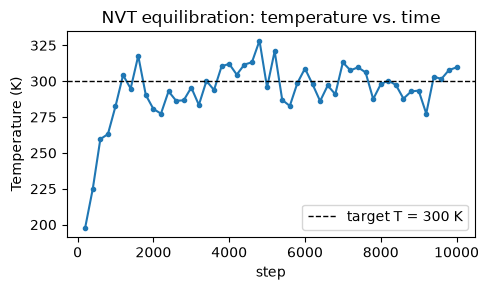

In [14]:
N_STEPS_NVT = 10000        # 10,000 x 2 fs = 20 ps
RECORD_EVERY_NVT = 200

simulation.context.setVelocitiesToTemperature(TEMPERATURE)

nvt_steps, nvt_temperature = [], []

t0 = time.time()
for i in range(N_STEPS_NVT // RECORD_EVERY_NVT):
    simulation.step(RECORD_EVERY_NVT)
    state = simulation.context.getState(getEnergy=True)
    T = temperature_kelvin(state, ndof)
    nvt_steps.append((i + 1) * RECORD_EVERY_NVT)
    nvt_temperature.append(T)
print(f"NVT equilibration ({N_STEPS_NVT} steps) finished in {time.time() - t0:.1f} s")

plt.figure(figsize=(5, 3))
plt.plot(nvt_steps, nvt_temperature, marker="o", ms=3)
plt.axhline(300, color="k", ls="--", lw=1, label="target T = 300 K")
plt.xlabel("step")
plt.ylabel("Temperature (K)")
plt.title("NVT equilibration: temperature vs. time")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
render_box(topology, positions_from_state(simulation), current_box_vectors(simulation),
           title="AFTER NVT equilibration: system thermalized at ~300 K, box volume still fixed")


AFTER NVT equilibration: system thermalized at ~300 K, box volume still fixed


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


## 8. Stage 3 — NPT equilibration (constant Number of particles, Pressure, Temperature)

Real experiments are usually done at constant *pressure*, not constant volume — the liquid is free to expand or contract. We now switch to the **NPT ensemble** using a `MonteCarloBarostat`, which periodically proposes small random changes to the box volume and accepts/rejects them so that, on average, the system samples configurations at the target pressure (1 atm).

We carry over the final positions, velocities and box size from the NVT stage into a *new* `Simulation` object built from the barostat-enabled `System` (see Section 5 for why we use two separate `System` objects).

Watch the **volume** and **density**: since we started the box more loosely packed than the real liquid (Section 4), we expect the barostat to shrink the box until the density approaches the experimental value of ethanol (~0.789 g/mL) — though, given the very short simulation time used here for teaching purposes, we should not expect full convergence.


In [16]:
# Carry the state from NVT over to a fresh NPT (barostat-enabled) simulation
nvt_state = simulation.context.getState(getPositions=True, getVelocities=True)
carried_positions = nvt_state.getPositions()
carried_velocities = nvt_state.getVelocities()
carried_box = current_box_vectors(simulation)

system_npt = make_system(topology, with_barostat=True)
simulation = make_simulation(topology, system_npt, carried_positions, carried_box, velocities=carried_velocities)
ndof = degrees_of_freedom(system_npt)

def compute_pressure_bar(simulation):
    """
    Instantaneous pressure from the virial theorem:
        P = (2*KE + virial) / (3*V),   virial = sum_i r_i . F_i
    This is the same relation you saw in the stat-mech part of the lecture --
    pressure is a *microscopic, fluctuating* quantity, only its time-average
    is expected to match the macroscopic pressure (here, the barostat's 1 atm target).
    """
    state = simulation.context.getState(getEnergy=True, getForces=True, getPositions=True)
    r = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    f = state.getForces(asNumpy=True).value_in_unit(unit.kilojoule_per_mole / unit.nanometer)
    ke = state.getKineticEnergy().value_in_unit(unit.kilojoule_per_mole)
    box = state.getPeriodicBoxVectors(asNumpy=True).value_in_unit(unit.nanometer)
    volume = np.linalg.det(box)
    virial = np.sum(r * f)
    P_kJ_mol_nm3 = (2 * ke + virial) / (3 * volume)
    return P_kJ_mol_nm3 * 16.6054  # kJ/mol/nm^3 -> bar

state = simulation.context.getState(getEnergy=True)
print(f"Potential energy at the start of NPT: {state.getPotentialEnergy()}")


Potential energy at the start of NPT: 2130.3577611193755 kJ/mol


In [17]:
N_STEPS_NPT_EQ = 20000     # 20,000 x 2 fs = 40 ps
RECORD_EVERY_NPT_EQ = 200
PRESSURE_EVERY = 500       # pressure needs getForces(), a bit more expensive -> sample less often

npt_eq_steps, npt_eq_temperature, npt_eq_volume, npt_eq_density, npt_eq_pressure = [], [], [], [], []

t0 = time.time()
for i in range(N_STEPS_NPT_EQ // RECORD_EVERY_NPT_EQ):
    simulation.step(RECORD_EVERY_NPT_EQ)
    step_no = (i + 1) * RECORD_EVERY_NPT_EQ

    state = simulation.context.getState(getEnergy=True)
    T = temperature_kelvin(state, ndof)
    box = current_box_vectors(simulation)
    V = box_volume_nm3(box)
    rho = density_g_per_mL(box)

    npt_eq_steps.append(step_no)
    npt_eq_temperature.append(T)
    npt_eq_volume.append(V)
    npt_eq_density.append(rho)

    if step_no % PRESSURE_EVERY == 0:
        npt_eq_pressure.append((step_no, compute_pressure_bar(simulation)))

print(f"NPT equilibration ({N_STEPS_NPT_EQ} steps) finished in {time.time() - t0:.1f} s")
print(f"Density: {npt_eq_density[0]:.3f} g/mL (start of NPT) -> {npt_eq_density[-1]:.3f} g/mL (end of NPT eq.)")


NPT equilibration (20000 steps) finished in 24.0 s
Density: 0.446 g/mL (start of NPT) -> 0.624 g/mL (end of NPT eq.)


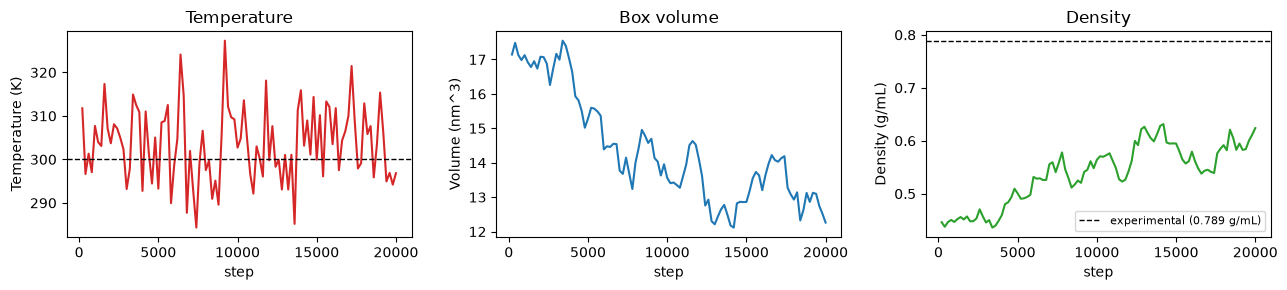

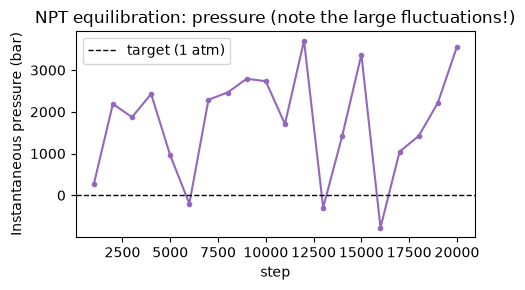

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(npt_eq_steps, npt_eq_temperature, color="tab:red")
axes[0].axhline(300, color="k", ls="--", lw=1)
axes[0].set_xlabel("step"); axes[0].set_ylabel("Temperature (K)"); axes[0].set_title("Temperature")

axes[1].plot(npt_eq_steps, npt_eq_volume, color="tab:blue")
axes[1].set_xlabel("step"); axes[1].set_ylabel("Volume (nm^3)"); axes[1].set_title("Box volume")

axes[2].plot(npt_eq_steps, npt_eq_density, color="tab:green")
axes[2].axhline(0.789, color="k", ls="--", lw=1, label="experimental (0.789 g/mL)")
axes[2].set_xlabel("step"); axes[2].set_ylabel("Density (g/mL)"); axes[2].set_title("Density")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

steps_p, values_p = zip(*npt_eq_pressure)
plt.figure(figsize=(5, 3))
plt.plot(steps_p, values_p, marker="o", ms=3, color="tab:purple")
plt.axhline(1.01325, color="k", ls="--", lw=1, label="target (1 atm)")
plt.xlabel("step"); plt.ylabel("Instantaneous pressure (bar)")
plt.title("NPT equilibration: pressure (note the large fluctuations!)")
plt.legend()
plt.tight_layout()
plt.show()



**Why does the instantaneous pressure fluctuate by hundreds or even thousands of bar around a 1 atm target?** This is completely normal for a small MD system (900 atoms here). Pressure is a collective, instantaneous property computed from a virial over a handful of particles; its statistical fluctuations scale roughly as $1/\sqrt{N}$. Only the **time-average** pressure over a long-enough trajectory is expected to match the barostat's target — which is exactly why we always report averaged, not instantaneous, thermodynamic quantities (Section 9).


In [25]:
render_box(topology, positions_from_state(simulation), current_box_vectors(simulation),
           title="AFTER NPT equilibration: box has shrunk toward the equilibrium liquid density")


AFTER NPT equilibration: box has shrunk toward the equilibrium liquid density


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


## 9. Stage 4 — NPT production and final analysis

The equilibration stages exist purely to bring the system to a representative state; we normally discard their data. The **production** run is the one we actually use to compute averages and report results.


In [26]:
N_STEPS_PROD = 20000     # 20,000 x 2 fs = 40 ps
RECORD_EVERY_PROD = 200

prod_steps, prod_T, prod_V, prod_rho, prod_P = [], [], [], [], []

t0 = time.time()
for i in range(N_STEPS_PROD // RECORD_EVERY_PROD):
    simulation.step(RECORD_EVERY_PROD)
    step_no = (i + 1) * RECORD_EVERY_PROD

    state = simulation.context.getState(getEnergy=True)
    T = temperature_kelvin(state, ndof)
    box = current_box_vectors(simulation)
    V = box_volume_nm3(box)
    rho = density_g_per_mL(box)
    P = compute_pressure_bar(simulation)

    prod_steps.append(step_no)
    prod_T.append(T)
    prod_V.append(V)
    prod_rho.append(rho)
    prod_P.append(P)

print(f"Production run ({N_STEPS_PROD} steps) finished in {time.time() - t0:.1f} s")


Production run (20000 steps) finished in 24.8 s


In [27]:
render_box(topology, positions_from_state(simulation), current_box_vectors(simulation),
           title="AFTER production: final configuration of the liquid ethanol box")


AFTER production: final configuration of the liquid ethanol box


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

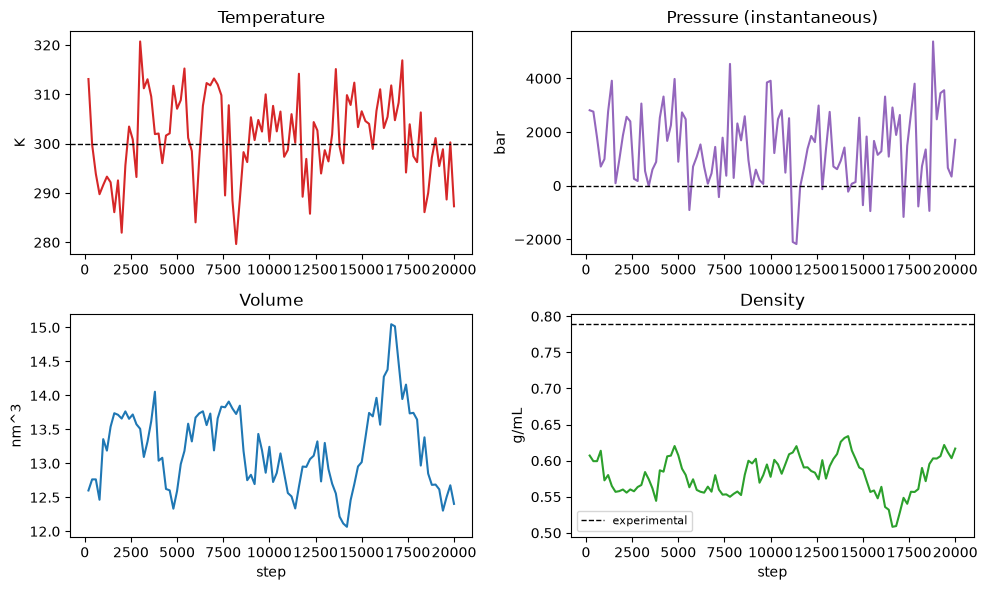

Production averages (mean +/- standard deviation):
  Temperature:  301.21 +/-  8.52 K
  Pressure:     1414.5 +/-  1437.1 bar   (target: 1.01 bar)
  Volume:        13.23 +/-  0.60 nm^3
  Density:       0.580 +/- 0.026 g/mL  (experimental: 0.789 g/mL)


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].plot(prod_steps, prod_T, color="tab:red")
axes[0, 0].axhline(300, color="k", ls="--", lw=1)
axes[0, 0].set_title("Temperature"); axes[0, 0].set_ylabel("K")

axes[0, 1].plot(prod_steps, prod_P, color="tab:purple")
axes[0, 1].axhline(1.01325, color="k", ls="--", lw=1)
axes[0, 1].set_title("Pressure (instantaneous)"); axes[0, 1].set_ylabel("bar")

axes[1, 0].plot(prod_steps, prod_V, color="tab:blue")
axes[1, 0].set_title("Volume"); axes[1, 0].set_ylabel("nm^3"); axes[1, 0].set_xlabel("step")

axes[1, 1].plot(prod_steps, prod_rho, color="tab:green")
axes[1, 1].axhline(0.789, color="k", ls="--", lw=1, label="experimental")
axes[1, 1].set_title("Density"); axes[1, 1].set_ylabel("g/mL"); axes[1, 1].set_xlabel("step")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Production averages (mean +/- standard deviation):")
print(f"  Temperature: {np.mean(prod_T):7.2f} +/- {np.std(prod_T):5.2f} K")
print(f"  Pressure:    {np.mean(prod_P):7.1f} +/- {np.std(prod_P):7.1f} bar   (target: 1.01 bar)")
print(f"  Volume:      {np.mean(prod_V):7.2f} +/- {np.std(prod_V):5.2f} nm^3")
print(f"  Density:     {np.mean(prod_rho):7.3f} +/- {np.std(prod_rho):5.3f} g/mL  (experimental: 0.789 g/mL)")



## 10. Discussion questions for the class

1. The mean instantaneous pressure has a very large standard deviation compared to its mean, yet we still trust that the barostat is doing the right thing. Why is looking at the **time-averaged** pressure the correct thing to do here, and what would you need to do to reduce the uncertainty on that average?
2. Our final density is probably still somewhat below the experimental 0.789 g/mL. List **all** the approximations we made in this notebook that could explain the gap (there are at least four), and rank them by how much you think each one matters.
3. We built the GAFF residue template "by hand", assigning atom types and charges ourselves. What would break if we had, instead, accidentally typed `O1` as `os` (ether oxygen) instead of `oh` (hydroxyl oxygen)? Which force field terms would be affected?
4. If we wanted to compute the enthalpy of vaporization of ethanol (a genuinely useful validation of a force field), what additional simulation(s) would we need to run, beyond what is in this notebook?
5. What would need to change in this notebook to simulate an ethanol-water mixture instead of pure ethanol?
